In [58]:
'''
#This is what i did for plotting radial stufs! 

#This was the gotchya code
#never delete this

#window = HanningWindow()
window = TukeyWindow(alpha=0.5)

# --------------------------------------------------
# Band selection
# --------------------------------------------------
def band_from_wavelength(lam):
    lam = float(lam)
    if 4.90 <= lam <= 5.74:   return "1A"
    if 5.66 <= lam <= 6.63:   return "1B"
    if 6.53 <= lam <= 7.65:   return "1C"
    if 7.51 <= lam <= 8.77:   return "2A"
    if 8.67 <= lam <= 10.13:  return "2B"
    if 10.01 <= lam <= 11.70: return "2C"
    if 11.55 <= lam <= 13.47: return "3A"
    if 13.34 <= lam <= 15.57: return "3B"
    if 15.41 <= lam <= 17.98: return "3C"
    raise ValueError(f"Wavelength {lam} µm outside MIRI MRS range")

# --------------------------------------------------
# Rest‑frame wavelengths for each line (from file names)
# --------------------------------------------------

rest_um = {
    "S9_5_0":    4.95,
    "S8_5_1":    5.05,
    "H6d_5_1":   5.13,
    "FeII_5_3":  5.34,
    "H7k_5_4":   5.38,
    "S7_5_5":    5.51,
    "H7i_5_5":   5.53,
    "MgV_5_6":   5.60,
    "H7t_5_7":   5.71,
    "S7_1-1_5_8":5.81,
    "H6g_5_9":   5.91,
    "H7e_6_0":   5.96,
    "S6_6_1":    6.11,
    "H7z_6_3":   6.29,
    "NiII_6_6":  6.64,
    "He_6_7":    6.72,
    "H7e_6_8":   6.77,
    "S5_6_9":    6.91,
    "ArII_7_0":  6.99,
    "NiIII_7_3": 7.35,
    "H5a_7_5":   7.46,
    "H5b_7_5":   7.50,
    "H7d_7_5":   7.51,
    "NeVI_7_7":  7.65,
    "H8t_7_8":   7.78,
    "S4_8_0":    8.03,
    "H7g_8_8":   8.76,
    "ArIII_9_0": 8.99,
    "S3_9_7":    9.66,
    "SIV_10_5":  10.51,
    "NiII_10_7": 10.68,
    "H7b_11_3":  11.31,
    "S2_12_3":   12.28,
    "H6a_12_4":  12.37,
    "H8g_12_4":  12.39,
    "NeII_12_8": 12.81,
    "MgV_13_5": 13.54,
    "C2H2_13_7": 13.70,
    "HCN_14_0": 14.0,
    "NeV_14_3":  14.32,
    "ClII_14_4": 14.37,
    "CO2_15_0": 15.0,
    "NeIII_15_6":15.56,
    "H8b_16_2":  16.21,
    "S1_17_0":   17.03,
    "PIII_17_9": 17.88,
}

def get_line_wavelength_from_dict(filename, rest_um):
    base = os.path.basename(filename)
    #base = base.replace("NGC253_", "").replace(".line.fits", "")
    base = base.replace("NGC253_", "").replace(".line_regrid.fits", "")
    name_key = base.replace(".", "_")
    if name_key in rest_um:
        return rest_um[name_key]
    raise RuntimeError(f"Line '{name_key}' not found in rest_um dictionary")

# --------------------------------------------------
# File directories
# --------------------------------------------------
IN_DIR   = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_regrid"
OUT_DIR  = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth"
TARGET_LAMBDA = 17.8846
TARGET_BAND   = "3C"
FILE_GLOB = os.path.join(IN_DIR, "*.line_regrid.fits")

os.makedirs(OUT_DIR, exist_ok=True)
files = sorted(glob(FILE_GLOB))

skipped_lines = []

miri_target = stpsf.MIRI()
miri_target.mode = "IFU"
miri_target.band = TARGET_BAND
pixscale_target =  0.2 #pixscale_native  # we still want same image scale
miri_target.pixelscale = pixscale_target
psf_target = miri_target.calc_psf(monochromatic=TARGET_LAMBDA * 1e-6)[3].data
print(TARGET_LAMBDA)
psf_target /= psf_target.sum()

###################################################################
#I am trying to check FWHM of this by creating Radial profile! 

# Find PSF center
yc, xc = np.unravel_index(np.argmax(psf_target), psf_target.shape)

# Maximum usable radius in pixels
ny, nx = psf_target.shape
max_radius_pix = min(xc, yc, nx-xc-1, ny-yc-1)

# Define radii safely within the PSF
radii = np.linspace(0, max_radius_pix, 120)

# Compute radial profile
rp = RadialProfile(psf_target, (xc, yc), radii)

# Extract radius and intensity
r = rp.radius
I = rp.profile

# Remove NaNs
mask = np.isfinite(I)
r = r[mask]
I = I[mask]

# Convert radius to arcseconds
r_arcsec_psf = r * pixscale_target

# Normalize intensity
I_norm = I / np.max(I)


def gaussian_with_bg_fixed_mu(r, A, sigma, C):
    return A * np.exp(-(r**2) / (2*sigma**2)) + C

# Initial guesses
A0 = np.max(I_norm)
sigma0 = 0.3  # arcsec, roughly for MIRI
C0 = 0.0
p0 = [A0, sigma0, C0]

# Fit Gaussian
popt, _ = curve_fit(gaussian_with_bg_fixed_mu, r_arcsec_psf, I_norm, p0=p0)
A_fit, sigma_psf_arcsec, C_fit = popt

FWHM_psf_arcsec = 2.355 * sigma_psf_arcsec

print("Gaussian fit sigma (arcsec):", sigma_psf_arcsec)
print("Gaussian FWHM (arcsec):", FWHM_psf_arcsec)

# Plot fit
r_fit = np.linspace(0, r_arcsec_psf.max(), 300)
I_fit = gaussian_with_bg_fixed_mu(r_fit, *popt)

plt.figure(figsize=(7,5))
plt.plot(r_arcsec_psf, I_norm, label='Radial Profile')
plt.plot(r_fit, I_fit, color='red', lw=2, label='Gaussian Fit')
plt.xlabel("Radius (arcsec)")
plt.ylabel("Normalized Intensity")
plt.title("PSF Radial Profile with Gaussian Fit of Target file")
plt.ylim(0, 1.1)
plt.xlim(0, 1.5)
plt.legend()
plt.show()


########################################################################

# --------------------------------------------------
# Main processing loop
# --------------------------------------------------
for infile in files:

    name = os.path.basename(infile)
    print(f"\nProcessing {name}")

    with fits.open(infile) as hdul:
        flux = hdul['SCI'].data.astype(np.float64)
        hdr  = hdul['SCI'].header.copy()
        pixscale_native = abs(hdr["CDELT2"]) * 3600.0  # native pixelscale

    try:
        lam_line = get_line_wavelength_from_dict(infile, rest_um)
        band_line = band_from_wavelength(lam_line)
    except RuntimeError as e:
        print("Skipping:", e)
        skipped_lines.append(name)
        continue

    print(f"  λ = {lam_line:.4f} µm | Band = {band_line}")

    # --------------------------------------------------
    # Generate PSFs
    # --------------------------------------------------

    miri_native = stpsf.MIRI()
    miri_native.mode = "IFU"
    miri_native.band = band_line
    miri_native.pixelscale = 0.2
    psf_native = miri_native.calc_psf(monochromatic=lam_line * 1e-6)[3].data
    psf_native /= psf_native.sum()


######################################################
    #plotting for selected file
    
    # Find PSF center
    yc, xc = np.unravel_index(np.argmax(psf_native), psf_native.shape)

    # Maximum usable radius in pixels
    ny, nx = psf_native.shape
    max_radius_pix = min(xc, yc, nx-xc-1, ny-yc-1)

    # Define radii safely within the PSF
    radii = np.linspace(0, max_radius_pix, 120)

    # Compute radial profile
    rp = RadialProfile(psf_native, (xc, yc), radii)

    # Extract radius and intensity
    r = rp.radius
    I = rp.profile

    # Remove NaNs
    mask = np.isfinite(I)
    r = r[mask]
    I = I[mask]

    # Convert radius to arcseconds
    r_arcsec_psf = r * pixscale_native

    # Normalize intensity
    I_norm = I / np.max(I)


    def gaussian_with_bg_fixed_mu(r, A, sigma, C):
        return A * np.exp(-(r**2) / (2*sigma**2)) + C

    # Initial guesses
    A0 = np.max(I_norm)
    sigma0 = 0.3  # arcsec, roughly for MIRI
    C0 = 0.0
    p0 = [A0, sigma0, C0]

    # Fit Gaussian
    popt, _ = curve_fit(gaussian_with_bg_fixed_mu, r_arcsec_psf, I_norm, p0=p0)
    A_fit, sigma_psf_arcsec, C_fit = popt

    FWHM_psf_arcsec = 2.355 * sigma_psf_arcsec

    print("Gaussian fit sigma (arcsec):", sigma_psf_arcsec)
    print("Gaussian FWHM (arcsec):", FWHM_psf_arcsec)

    # Plot fit
    r_fit = np.linspace(0, r_arcsec_psf.max(), 300)
    I_fit = gaussian_with_bg_fixed_mu(r_fit, *popt)

    plt.figure(figsize=(7,5))
    plt.plot(r_arcsec_psf, I_norm, label='Radial Profile')
    plt.plot(r_fit, I_fit, color='red', lw=2, label='Gaussian Fit')
    plt.xlabel("Radius (arcsec)")
    plt.ylabel("Normalized Intensity")
    plt.title("PSF Radial Profile with Gaussian Fit of Native file")
    plt.ylim(0, 1.1)
    plt.xlim(0, 1.5)
    plt.legend()
    plt.show()


    def center_psf(psf):
        yc, xc = np.unravel_index(np.argmax(psf), psf.shape)
        cy = (psf.shape[0]-1)/2
        cx = (psf.shape[1]-1)/2
        return shift(psf, (cy-yc, cx-xc), order=3)

    psf_native = center_psf(psf_native)
    psf_target = center_psf(psf_target)

########################################################################

    # --------------------------------------------------
    # Resize native PSF to target PSF using photutils  **https://photutils.readthedocs.io/en/stable/api/photutils.psf.matching.resize_psf.html#photutils.psf.matching.resize_psf
    # --------------------------------------------------
    psf_native= resize_psf(psf_native,
                                    input_pixel_scale=pixscale_native,
                                    output_pixel_scale=pixscale_target,
                                    order=3)

    # --------------------------------------------------
    # Create matching kernel  **https://photutils.readthedocs.io/en/stable/user_guide/psf_matching.html#
    # --------------------------------------------------
    kernel = create_matching_kernel(psf_native, psf_target,
                                    window=window)

    # --------------------------------------------------
    # Diagnostic: kernel center check
    # --------------------------------------------------
    y, x = np.indices(kernel.shape)
    total = kernel.sum()

    cy_float = (y * kernel).sum() / total
    cx_float = (x * kernel).sum() / total

    cy_nom = (kernel.shape[0] - 1) / 2.0
    cx_nom = (kernel.shape[1] - 1) / 2.0

    offset_y = cy_float - cy_nom
    offset_x = cx_float - cx_nom
    print("Kernel subpixel offset (y, x):", (offset_y, offset_x))

    print("Kernel min:", kernel.min())
    print("Kernel max:", kernel.max())
    print("Kernel sum:", kernel.sum())
    
    from scipy.ndimage import shift

    kernel = shift(kernel, shift=(-offset_y, -offset_x), order=3)
    kernel /= kernel.sum()

    # --------------------------------------------------
    # Diagnostic: kernel center check
    # --------------------------------------------------
    y, x = np.indices(kernel.shape)
    total = kernel.sum()

    cy_float = (y * kernel).sum() / total
    cx_float = (x * kernel).sum() / total

    cy_nom = (kernel.shape[0] - 1) / 2.0
    cx_nom = (kernel.shape[1] - 1) / 2.0

    offset_y = cy_float - cy_nom
    offset_x = cx_float - cx_nom
    print("Kernel subpixel offset after correction (y, x):", (offset_y, offset_x))

    # --------------------------------------------------
    # Check FWHM of PSF after applying kernel
    # --------------------------------------------------
    psf_conv = fftconvolve(psf_native, kernel, mode='same')

    # radial profile
    yc, xc = np.unravel_index(np.argmax(psf_conv), psf_conv.shape)
    radii = np.linspace(0, min(xc, yc, psf_conv.shape[1]-xc-1, psf_conv.shape[0]-yc-1), 120)
    rp = RadialProfile(psf_conv, (xc, yc), radii)
    r = rp.radius * pixscale_target
    I = rp.profile / np.max(rp.profile)

    # Gaussian fit
    p0 = [1.0, 0.3, 0.0]
    popt, _ = curve_fit(gaussian_with_bg_fixed_mu, r, I, p0=p0)
    FWHM_conv = 2.355 * popt[1]
    print("FWHM after convolution:", FWHM_conv)



    # --------------------------------------------------
    # Diagnostic plot (All files)
    # --------------------------------------------------
    def plot_psf(psf, title):
        plt.figure(figsize=(4,3.2))
        plt.imshow(psf, origin='lower', cmap='magma',
                       norm=LogNorm(vmin=psf.max()*1e-5,
                                    vmax=psf.max()))
        plt.colorbar()
        plt.title(title)
        plt.tight_layout()
        plt.show()

    #plot_psf(psf_native_resized, "Native PSF (resized)")
    plot_psf(psf_native, "Native PSF (resized)")
    plot_psf(psf_target, "Target PSF")
    plot_psf(kernel, "Matching Kernel")

    # Residual diagnostic
    test = fftconvolve(psf_native, kernel, mode="same")
    resid = test - psf_target
    print("Residual RMS:", np.sqrt(np.nanmean(resid**2)))

    # --------------------------------------------------
    # Convolve cube
    # --------------------------------------------------
    sm_flux = np.zeros_like(flux)
    for i in range(flux.shape[0]):
        img = np.nan_to_num(flux[i], nan=0.0)
        mask = ~np.isnan(flux[i])
        sm = fftconvolve(img, kernel, mode="same")
        sm[~mask] = np.nan
        sm_flux[i] = sm

    # --------------------------------------------------
    # Save output
    # --------------------------------------------------
    outname = os.path.join(OUT_DIR, name.replace(".fits", "_smooth.fits"))
    fits.writeto(outname, sm_flux, hdr, overwrite=True)
    print("  → Saved", outname)

# --------------------------------------------------
# Summary
# --------------------------------------------------
if skipped_lines:
    print("\nSkipped files:")
    for f in skipped_lines:
        print("   ", f)

print("\nAll available line maps PSF-homogenized using resize_psf().")

'''

'\n#This is what i did for plotting radial stufs! \n\n#This was the gotchya code\n#never delete this\n\n#window = HanningWindow()\nwindow = TukeyWindow(alpha=0.5)\n\n# --------------------------------------------------\n# Band selection\n# --------------------------------------------------\ndef band_from_wavelength(lam):\n    lam = float(lam)\n    if 4.90 <= lam <= 5.74:   return "1A"\n    if 5.66 <= lam <= 6.63:   return "1B"\n    if 6.53 <= lam <= 7.65:   return "1C"\n    if 7.51 <= lam <= 8.77:   return "2A"\n    if 8.67 <= lam <= 10.13:  return "2B"\n    if 10.01 <= lam <= 11.70: return "2C"\n    if 11.55 <= lam <= 13.47: return "3A"\n    if 13.34 <= lam <= 15.57: return "3B"\n    if 15.41 <= lam <= 17.98: return "3C"\n    raise ValueError(f"Wavelength {lam} µm outside MIRI MRS range")\n\n# --------------------------------------------------\n# Rest‑frame wavelengths for each line (from file names)\n# --------------------------------------------------\n\nrest_um = {\n    "S9_5_0":  

In [59]:
# All imports stays here

import os
import sys

import astropy.units as u
from astropy.convolution import convolve_fft
from astropy.io import fits
from astropy.wcs import WCS

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import numpy as np

from glob import glob

from reproject import reproject_interp

from scipy.fftpack import fft2, ifft2, fftshift, ifftshift
from scipy.signal import fftconvolve

from spectral_cube import SpectralCube

import stpsf

from tqdm.notebook import tqdm

from photutils.psf.matching import create_matching_kernel, TukeyWindow, HanningWindow, resize_psf

from photutils.profiles import RadialProfile
from scipy.optimize import curve_fit

from scipy.ndimage import shift


Processing NGC253_ArIII_9.0.line.fits
  λ = 8.9900 µm | Band = 2B


/Users/u826s018/miniconda3/envs/nearbygalaxies/lib/python3.11/site-packages/stpsf/opds.py:1759: UserWarning: For (V2,V3) = [-8.399315 -5.319645] arcmin, Field point -8.254199999999999 arcmin, -2.480355000000001 arcmin not within valid region for field dependence model of OTE WFE for MIRI: -8.254199999999999 arcmin--6.21738 arcmin, -2.557224 arcmin--0.5632056 arcmin.  Clipping to closest available valid location, 0.14511500000000055 arcmin away from the requested coordinates.
  warnings.warn(warning_message)
/Users/u826s018/miniconda3/envs/nearbygalaxies/lib/python3.11/site-packages/stpsf/opds.py:1759: UserWarning: For (V2,V3) = [-8.39228333 -5.32616667] arcmin, Field point -8.254199999999999 arcmin, -2.473833333333334 arcmin not within valid region for field dependence model of OTE WFE for MIRI: -8.254199999999999 arcmin--6.21738 arcmin, -2.557224 arcmin--0.5632056 arcmin.  Clipping to closest available valid location, 0.13808333333333422 arcmin away from the requested coordinates.
  w

Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.0014300466611722469
Kernel max: 0.06589546902835863
Kernel sum: 1.0


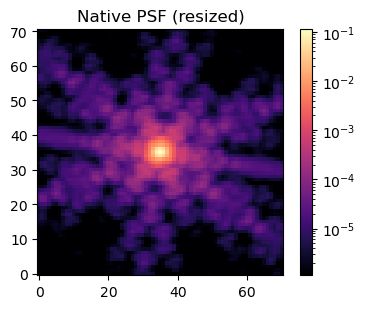

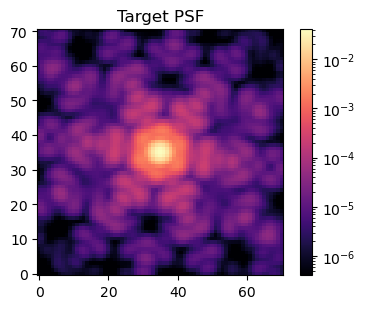

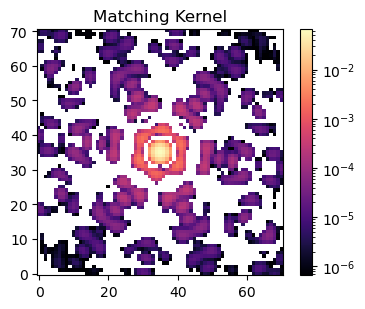

Residual RMS: 0.00020539133382589396
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_ArIII_9.0.line_smooth.fits

Processing NGC253_ArII_7.0.line.fits
  λ = 6.9900 µm | Band = 1C


/Users/u826s018/miniconda3/envs/nearbygalaxies/lib/python3.11/site-packages/stpsf/opds.py:1759: UserWarning: For (V2,V3) = [-8.38815333 -5.31410167] arcmin, Field point -8.254199999999999 arcmin, -2.485898333333334 arcmin not within valid region for field dependence model of OTE WFE for MIRI: -8.254199999999999 arcmin--6.21738 arcmin, -2.557224 arcmin--0.5632056 arcmin.  Clipping to closest available valid location, 0.13395333333333426 arcmin away from the requested coordinates.
  warnings.warn(warning_message)


Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.0006655344668817907
Kernel max: 0.037527471993489395
Kernel sum: 1.0
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_ArII_7.0.line_smooth.fits

Processing NGC253_C2H2_13.7.line.fits
  λ = 13.7000 µm | Band = 3B


/Users/u826s018/miniconda3/envs/nearbygalaxies/lib/python3.11/site-packages/stpsf/opds.py:1759: UserWarning: For (V2,V3) = [-8.40143167 -5.31995333] arcmin, Field point -8.254199999999999 arcmin, -2.4800466666666674 arcmin not within valid region for field dependence model of OTE WFE for MIRI: -8.254199999999999 arcmin--6.21738 arcmin, -2.557224 arcmin--0.5632056 arcmin.  Clipping to closest available valid location, 0.14723166666666643 arcmin away from the requested coordinates.
  warnings.warn(warning_message)


Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.004782010279146782
Kernel max: 0.1177135069391239
Kernel sum: 1.0
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_C2H2_13.7.line_smooth.fits

Processing NGC253_CO2_15.0.line.fits
  λ = 15.0000 µm | Band = 3B
Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.006631640593564044
Kernel max: 0.12866549732773425
Kernel sum: 1.0
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_CO2_15.0.line_smooth.fits

Processing NGC253_ClII_14.4.line.fits
  λ = 14.3700 µm | Band = 3B
Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.005719409391507049
Kernel max: 0.1244287217626603
Kernel sum: 1.0
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_ClII_14.4.line_smooth.fits

Processing NGC253_FeII_5.3.line.fits
  λ = 5.3400 µm | Band = 1A


...

Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.0004124741048026778
Kernel max: 0.035296067050508424
Kernel sum: 1.0
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_H6g_5.9.line_smooth.fits

Processing NGC253_H7b_11.3.line.fits
  λ = 11.3100 µm | Band = 2C


/Users/u826s018/miniconda3/envs/nearbygalaxies/lib/python3.11/site-packages/stpsf/opds.py:1759: UserWarning: For (V2,V3) = [-8.38974833 -5.32495833] arcmin, Field point -8.254199999999999 arcmin, -2.4750416666666677 arcmin not within valid region for field dependence model of OTE WFE for MIRI: -8.254199999999999 arcmin--6.21738 arcmin, -2.557224 arcmin--0.5632056 arcmin.  Clipping to closest available valid location, 0.13554833333333427 arcmin away from the requested coordinates.
  warnings.warn(warning_message)


Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.003270519380875824
Kernel max: 0.07532741794235062
Kernel sum: 0.9999999999999999
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_H7b_11.3.line_smooth.fits

Processing NGC253_H7d_7.5.line.fits
  λ = 7.5100 µm | Band = 1C
Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.0008167187524165453
Kernel max: 0.03870005945294243
Kernel sum: 1.0
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_H7d_7.5.line_smooth.fits

Processing NGC253_H7e_6.0.line.fits
  λ = 5.9600 µm | Band = 1B
Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.0004237960155203046
Kernel max: 0.03539433685688113
Kernel sum: 1.0
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_H7e_6.0.line_smooth.fits

Processing NGC253_H7e_6.8.line.fits
  λ = 6.7700 µm | Band = 1C
Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.0006124071

/Users/u826s018/miniconda3/envs/nearbygalaxies/lib/python3.11/site-packages/stpsf/opds.py:1759: UserWarning: For (V2,V3) = [-8.39108833 -5.32144667] arcmin, Field point -8.254199999999999 arcmin, -2.478553333333333 arcmin not within valid region for field dependence model of OTE WFE for MIRI: -8.254199999999999 arcmin--6.21738 arcmin, -2.557224 arcmin--0.5632056 arcmin.  Clipping to closest available valid location, 0.13688833333333505 arcmin away from the requested coordinates.
  warnings.warn(warning_message)


Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.0013136435308630512
Kernel max: 0.0650117175253029
Kernel sum: 1.0
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_H7g_8.8.line_smooth.fits

Processing NGC253_H7i_5.5.line.fits
  λ = 5.5300 µm | Band = 1A
Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.00032780150379144797
Kernel max: 0.03457154928342401
Kernel sum: 1.0
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_H7i_5.5.line_smooth.fits

Processing NGC253_H7k_5.4.line.fits
  λ = 5.3800 µm | Band = 1A
Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.00029435413781933866
Kernel max: 0.034289611829628266
Kernel sum: 1.0
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_H7k_5.4.line_smooth.fits

Processing NGC253_H7t_5.7.line.fits
  λ = 5.7100 µm | Band = 1A
Kernel offset: (np.int64(0), np.int64(0))
Kernel min: -0.00036814956391592916
Ke

In [60]:
#This was the gotchya code
#never delete this

window = HanningWindow()
#window = TukeyWindow(alpha=0.5)

# --------------------------------------------------
# Band selection
# --------------------------------------------------
def band_from_wavelength(lam):
    lam = float(lam)
    if 4.90 <= lam <= 5.74:   return "1A"
    if 5.66 <= lam <= 6.63:   return "1B"
    if 6.53 <= lam <= 7.65:   return "1C"
    if 7.51 <= lam <= 8.77:   return "2A"
    if 8.67 <= lam <= 10.13:  return "2B"
    if 10.01 <= lam <= 11.70: return "2C"
    if 11.55 <= lam <= 13.47: return "3A"
    if 13.34 <= lam <= 15.57: return "3B"
    if 15.41 <= lam <= 17.98: return "3C"
    raise ValueError(f"Wavelength {lam} µm outside MIRI MRS range")

# --------------------------------------------------
# Rest‑frame wavelengths for each line (from file names)
# --------------------------------------------------

rest_um = {
    "S9_5_0":    4.95,
    "S8_5_1":    5.05,
    "H6d_5_1":   5.13,
    "FeII_5_3":  5.34,
    "H7k_5_4":   5.38,
    "S7_5_5":    5.51,
    "H7i_5_5":   5.53,
    "MgV_5_6":   5.60,
    "H7t_5_7":   5.71,
    "S7_1-1_5_8":5.81,
    "H6g_5_9":   5.91,
    "H7e_6_0":   5.96,
    "S6_6_1":    6.11,
    "H7z_6_3":   6.29,
    "NiII_6_6":  6.64,
    "He_6_7":    6.72,
    "H7e_6_8":   6.77,
    "S5_6_9":    6.91,
    "ArII_7_0":  6.99,
    "NiIII_7_3": 7.35,
    "H5a_7_5":   7.46,
    "H5b_7_5":   7.50,
    "H7d_7_5":   7.51,
    "NeVI_7_7":  7.65,
    "H8t_7_8":   7.78,
    "S4_8_0":    8.03,
    "H7g_8_8":   8.76,
    "ArIII_9_0": 8.99,
    "S3_9_7":    9.66,
    "SIV_10_5":  10.51,
    "NiII_10_7": 10.68,
    "H7b_11_3":  11.31,
    "S2_12_3":   12.28,
    "H6a_12_4":  12.37,
    "H8g_12_4":  12.39,
    "NeII_12_8": 12.81,
    "MgV_13_5": 13.54,
    "C2H2_13_7": 13.70,
    "HCN_14_0": 14.0,
    "NeV_14_3":  14.32,
    "ClII_14_4": 14.37,
    "CO2_15_0": 15.0,
    "NeIII_15_6":15.56,
    "H8b_16_2":  16.21,
    "S1_17_0":   17.03,
    "PIII_17_9": 17.88,
}

def get_line_wavelength_from_dict(filename, rest_um):
    base = os.path.basename(filename)
    base = base.replace("NGC253_", "").replace(".line.fits", "")
    name_key = base.replace(".", "_")
    if name_key in rest_um:
        return rest_um[name_key]
    raise RuntimeError(f"Line '{name_key}' not found in rest_um dictionary")

# --------------------------------------------------
# File directories
# --------------------------------------------------
IN_DIR   = "../../github/astr796_25_V2/NGC253_output/3channel/casa/atomic"
OUT_DIR  = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth"
TARGET_LAMBDA = 17.8846
TARGET_BAND   = "3C"
FILE_GLOB = os.path.join(IN_DIR, "*.line.fits")

os.makedirs(OUT_DIR, exist_ok=True)
files = sorted(glob(FILE_GLOB))

skipped_lines = []

# --------------------------------------------------
# Main processing loop
# --------------------------------------------------
for infile in files:

    name = os.path.basename(infile)
    print(f"\nProcessing {name}")

    with fits.open(infile) as hdul:
        flux = hdul['SCI'].data.astype(np.float64)
        hdr  = hdul['SCI'].header.copy()
        pixscale_native = abs(hdr["CDELT2"]) * 3600.0  # native pixelscale

    try:
        lam_line = get_line_wavelength_from_dict(infile, rest_um)
        band_line = band_from_wavelength(lam_line)
    except RuntimeError as e:
        print("Skipping:", e)
        skipped_lines.append(name)
        continue

    print(f"  λ = {lam_line:.4f} µm | Band = {band_line}")

    # --------------------------------------------------
    # Generate PSFs
    # --------------------------------------------------
    miri_target = stpsf.MIRI()
    miri_target.mode = "IFU"
    miri_target.band = TARGET_BAND
    pixscale_target =  pixscale_native  # we still want same image scale
    miri_target.pixelscale = pixscale_target
    psf_target = miri_target.calc_psf(monochromatic=TARGET_LAMBDA * u.micron)[3].data
    psf_target /= psf_target.sum()


    miri_native = stpsf.MIRI()
    miri_native.mode = "IFU"
    miri_native.band = band_line
    miri_native.pixelscale = pixscale_native
    psf_native = miri_native.calc_psf(monochromatic=lam_line * u.micron)[3].data
    psf_native /= psf_native.sum()


    # --------------------------------------------------
    # Resize native PSF to target PSF using photutils  **https://photutils.readthedocs.io/en/stable/api/photutils.psf.matching.resize_psf.html#photutils.psf.matching.resize_psf
    # --------------------------------------------------
    psf_native_resized = resize_psf(psf_native,
                                    input_pixel_scale=pixscale_native,
                                    output_pixel_scale=pixscale_target,
                                    order=3)

    # --------------------------------------------------
    # Create matching kernel  **https://photutils.readthedocs.io/en/stable/user_guide/psf_matching.html#
    # --------------------------------------------------
    kernel = create_matching_kernel(psf_native_resized, psf_target,
                                    window=window)


    # --------------------------------------------------
    # Diagnostic: kernel center check
    # --------------------------------------------------
    peak_y, peak_x = np.unravel_index(np.argmax(kernel), kernel.shape)
    cy, cx = kernel.shape[0]//2, kernel.shape[1]//2
    print("Kernel offset:", (peak_y - cy, peak_x - cx))

    print("Kernel min:", kernel.min())
    print("Kernel max:", kernel.max())
    print("Kernel sum:", kernel.sum())

    # --------------------------------------------------
    # Diagnostic plot (first file only)
    # --------------------------------------------------
    if infile == files[0]:
        def plot_psf(psf, title):
            plt.figure(figsize=(4,3.2))
            plt.imshow(psf, origin='lower', cmap='magma',
                       norm=LogNorm(vmin=psf.max()*1e-5,
                                    vmax=psf.max()))
            plt.colorbar()
            plt.title(title)
            plt.tight_layout()
            plt.show()

        plot_psf(psf_native_resized, "Native PSF (resized)")
        plot_psf(psf_target, "Target PSF")
        plot_psf(kernel, "Matching Kernel")

        # Residual diagnostic
        test = fftconvolve(psf_native_resized, kernel, mode="same")
        resid = test - psf_target
        print("Residual RMS:", np.sqrt(np.nanmean(resid**2)))

    # --------------------------------------------------
    # Convolve cube
    # --------------------------------------------------
    sm_flux = np.zeros_like(flux)
    for i in range(flux.shape[0]):
        img = np.nan_to_num(flux[i], nan=0.0)
        mask = ~np.isnan(flux[i])
        sm = fftconvolve(img, kernel, mode="same")
        sm[~mask] = np.nan
        sm_flux[i] = sm

    # --------------------------------------------------
    # Save output
    # --------------------------------------------------
    outname = os.path.join(OUT_DIR, name.replace(".fits", "_smooth.fits"))
    fits.writeto(outname, sm_flux, hdr, overwrite=True)
    print("  → Saved", outname)

# --------------------------------------------------
# Summary
# --------------------------------------------------
if skipped_lines:
    print("\nSkipped files:")
    for f in skipped_lines:
        print("   ", f)

print("\nAll available line maps PSF-homogenized using resize_psf().")


In [61]:
# This is regrdding
# One thing that I have done here
# Is passed the flux header to the data


# --- paths ---
smooth_dir = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth"
out_dir = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_regrid"
os.makedirs(out_dir, exist_ok=True)

# Reference cube (Fe II or ch4)
ref_path = os.path.join(smooth_dir, "NGC253_PIII_17.9.line_smooth.fits")
with fits.open(ref_path) as ref_hdul:
    ref_hdr = ref_hdul[0].header.copy()
    ref_data = ref_hdul[0].data.copy()
ref_wcs_3d = WCS(ref_hdr)
ref_wcs_2d = ref_wcs_3d.dropaxis(2)
ref_hdr_2d = ref_wcs_2d.to_header()
ny_ref, nx_ref = ref_data.shape[1], ref_data.shape[2]
shape_out_ref = (ny_ref, nx_ref)

# --- Input cubes ---
cube_files = sorted(glob(os.path.join(smooth_dir, "*.fits")))
print(f"Found {len(cube_files)} smoothed cubes.")

for infile in cube_files:
    name = os.path.basename(infile)
    outfile = os.path.join(out_dir, name.replace(".fits", "_regrid.fits"))

    # --- Read input cube ---
    data_in = fits.getdata(infile)
    hdr_in = fits.getheader(infile)
    wcs_in_3d = WCS(hdr_in)
    wcs_in_2d = wcs_in_3d.dropaxis(2)
    hdr_in_2d = wcs_in_2d.to_header()

    nlam = data_in.shape[0]
    print(f"Regridding {name}: {nlam} slices -> {shape_out_ref}")

    # --- Reproject slice by slice ---
    regridded = np.empty((nlam, ny_ref, nx_ref), dtype=np.float32)
    for i in range(nlam):
        plane = data_in[i].astype(float)
        plane_masked = np.where(np.isfinite(plane), plane, np.nan)
        out_plane, _ = reproject_interp((plane_masked, hdr_in_2d),
                                        ref_hdr_2d, shape_out=shape_out_ref)
        regridded[i] = out_plane

    # --- Build output header ---
    out_hdr = ref_hdr.copy()
    out_hdr["NAXIS3"] = nlam
    for key in hdr_in:
        if "3" in key or key.startswith("REST") or key.startswith("SPECSYS"):
            out_hdr[key] = hdr_in[key]

    fits.writeto(outfile, regridded, out_hdr, overwrite=True)
    print(f"  → wrote {outfile} shape={regridded.shape}")

print("All smoothed cubes regridded successfully.")


Found 46 smoothed cubes.
Regridding NGC253_ArIII_9.0.line_smooth.fits: 53 slices -> (93, 75)
  → wrote ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_regrid/NGC253_ArIII_9.0.line_smooth_regrid.fits shape=(53, 93, 75)
Regridding NGC253_ArII_7.0.line_smooth.fits: 67 slices -> (93, 75)
  → wrote ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_regrid/NGC253_ArII_7.0.line_smooth_regrid.fits shape=(67, 93, 75)
Regridding NGC253_C2H2_13.7.line_smooth.fits: 42 slices -> (93, 75)
  → wrote ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_regrid/NGC253_C2H2_13.7.line_smooth_regrid.fits shape=(42, 93, 75)
Regridding NGC253_CO2_15.0.line_smooth.fits: 47 slices -> (93, 75)
  → wrote ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_regrid/NGC253_CO2_15.0.line_smooth_regrid.fits shape=(47, 93, 75)
Regridding NGC253_ClII_14.4.line_smooth.fits: 45 slices -> (93, 75)
  → wrote ../../github/astr796_25_V2/NGC253_output/3channel/jws

In [62]:
# Masking the regridded file to ch1 footprint

# ---- Paths ----
input_dir = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/v2/line_regrid"          #use this for frequency based x axis
output_dir = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/v2/line_masked"

os.makedirs(output_dir, exist_ok=True)

# ---- Reference Ch I cube for mask ----
ch1_ref = os.path.join(input_dir, "NGC253_S9_5.0.line_smooth_regrid.fits")         #for frequency based maps
if not os.path.exists(ch1_ref):
    raise FileNotFoundError(f"Ch 1 reference cube not found: {ch1_ref}")

fe_data = fits.getdata(ch1_ref)
if fe_data.ndim != 3:
    raise RuntimeError(f"Ch I cube not 3D: shape={fe_data.shape}")

mask = np.ones_like(fe_data[0], dtype=float)
mask[~np.isfinite(fe_data[0])] = np.nan
print(f" Mask built from Ch I first plane: shape={mask.shape}")

# ---- Apply mask to each cube ----
for fname in sorted(os.listdir(input_dir)):
    if not fname.endswith(".fits"):
        continue
    infile = os.path.join(input_dir, fname)
    data = fits.getdata(infile)
    hdr = fits.getheader(infile)

    if data.ndim != 3:
        print(f"Skipping {fname} (not 3D)")
        continue

    # Apply mask: NaN where Ch I is invalid
    data_masked = data * mask[np.newaxis, :, :]

    # Write masked cube
    outfile = os.path.join(output_dir, fname.replace(".fits", "_maskch1.fits"))
    fits.writeto(outfile, data_masked, hdr, overwrite=True)
    print(f"→ Masked {fname}  →  {os.path.basename(outfile)}")

print("All cubes masked using ch1 S9 reference.")


 Mask built from Ch I first plane: shape=(93, 75)
→ Masked NGC253_ArIII_9.0.line_smooth_regrid.fits  →  NGC253_ArIII_9.0.line_smooth_regrid_maskch1.fits
→ Masked NGC253_ArII_7.0.line_smooth_regrid.fits  →  NGC253_ArII_7.0.line_smooth_regrid_maskch1.fits
→ Masked NGC253_C2H2_13.7.line_smooth_regrid.fits  →  NGC253_C2H2_13.7.line_smooth_regrid_maskch1.fits
→ Masked NGC253_CO2_15.0.line_smooth_regrid.fits  →  NGC253_CO2_15.0.line_smooth_regrid_maskch1.fits
→ Masked NGC253_ClII_14.4.line_smooth_regrid.fits  →  NGC253_ClII_14.4.line_smooth_regrid_maskch1.fits
→ Masked NGC253_FeII_5.3.line_smooth_regrid.fits  →  NGC253_FeII_5.3.line_smooth_regrid_maskch1.fits
→ Masked NGC253_H5a_7.5.line_smooth_regrid.fits  →  NGC253_H5a_7.5.line_smooth_regrid_maskch1.fits
→ Masked NGC253_H5b_7.5.line_smooth_regrid.fits  →  NGC253_H5b_7.5.line_smooth_regrid_maskch1.fits
→ Masked NGC253_H6a_12.4.line_smooth_regrid.fits  →  NGC253_H6a_12.4.line_smooth_regrid_maskch1.fits
→ Masked NGC253_H6d_5.1.line_smooth_reg

In [63]:
raise SystemError('Pause')

SystemError: Pause

## Full cube version

In [ ]:
import os
import sys
import numpy as np
from tqdm import tqdm
from astropy.io import fits
import astropy.units as u
from scipy.ndimage import shift as nd_shift
from scipy.signal import fftconvolve
from photutils.psf.matching import create_matching_kernel, resize_psf
from photutils.psf.matching import HanningWindow  # or TukeyWindow

window = HanningWindow()
# window = TukeyWindow(alpha=0.5)

# --------------------------------------------------
# Band selection
# --------------------------------------------------
def band_from_wavelength(lam):
    lam = float(lam)
    if 4.90 <= lam <= 5.74:   return "1A"
    if 5.66 <= lam <= 6.63:   return "1B"
    if 6.53 <= lam <= 7.65:   return "1C"
    if 7.51 <= lam <= 8.77:   return "2A"
    if 8.67 <= lam <= 10.13:  return "2B"
    if 10.01 <= lam <= 11.70: return "2C"
    if 11.55 <= lam <= 13.47: return "3A"
    if 13.34 <= lam <= 15.57: return "3B"
    if 15.41 <= lam <= 17.99: return "3C"
    raise ValueError(f"Wavelength {lam} µm outside MIRI MRS range")

# --------------------------------------------------
# Recentering helper
# --------------------------------------------------
def recenter_psf(psf, method="centroid"):
    """
    Shift PSF so its centroid (or peak) lies at the nominal center.
    """
    cy = (psf.shape[0] - 1) / 2.0
    cx = (psf.shape[1] - 1) / 2.0

    if method == "max_peak":
        peak_y, peak_x = np.unravel_index(np.nanargmax(psf), psf.shape)
        dy = cy - peak_y
        dx = cx - peak_x

    elif method == "centroid":
        y, x = np.indices(psf.shape)
        total = psf.sum()
        peak_y = (y * psf).sum() / total
        peak_x = (x * psf).sum() / total
        dy = cy - peak_y
        dx = cx - peak_x

    else:
        raise ValueError("method must be 'max_peak' or 'centroid'")

    psf_rec = nd_shift(psf, shift=(dy, dx), order=3, mode='constant', cval=0.0)
    return psf_rec, (dy, dx)

# --------------------------------------------------
# Main smoothing function
# --------------------------------------------------
def smooth_cube_to_target_psf(infile, outfile, target_wavelength=17.98):

    with fits.open(infile) as hdul:
        flux = hdul['SCI'].data.astype(np.float64)
        err  = hdul['ERR'].data.astype(np.float64)
        sci_hdr = hdul['SCI'].header.copy()

    nlam = sci_hdr["NAXIS3"]
    lambdas = ((np.arange(nlam) - (sci_hdr["CRPIX3"] - 1)) *
               sci_hdr["CDELT3"] + sci_hdr["CRVAL3"])
    pixscale = abs(sci_hdr["CDELT2"]) * 3600.0  # arcsec/pix

    sm_flux = np.empty_like(flux)
    sm_err  = np.full_like(err, np.nan)

    # --------------------------------------------------
    # Precompute target PSF once
    # --------------------------------------------------
    target_band = band_from_wavelength(target_wavelength)
    print(f"Computing target PSF at λ = {target_wavelength:.4f} µm (band {target_band})")

    miri_target = stpsf.MIRI()
    miri_target.mode = 'IFU'
    miri_target.band = target_band
    pixscale_target = 0.196
    miri_target.pixelscale = pixscale_target

    psf_target_base = miri_target.calc_psf(monochromatic=target_wavelength * 1e-6)[3].data.astype(float)
    psf_target_base /= psf_target_base.sum()

    # --------------------------------------------------
    # Loop over slices
    # --------------------------------------------------
    pbar = tqdm(range(nlam), desc="Smoothing slices", file=sys.stdout)
    for i in pbar:

        lam = lambdas[i]
        band = band_from_wavelength(lam)

        # --- Native PSF ---
        miri = stpsf.MIRI()
        miri.mode = 'IFU'
        miri.band = band
        miri.pixelscale = pixscale
        psf_native = miri.calc_psf(monochromatic=lam * 1e-6)[3].data.astype(float)
        psf_native /= psf_native.sum()

        # --- Resize native PSF to target pixel scale ---
        psf_native = resize_psf(psf_native,
                                input_pixel_scale=pixscale,
                                output_pixel_scale=pixscale_target,
                                order=3)

        # --- Pad both PSFs to same (odd) size ---
        h = max(psf_native.shape[0], psf_target_base.shape[0])
        w = max(psf_native.shape[1], psf_target_base.shape[1])
        if h % 2 == 0: h += 1
        if w % 2 == 0: w += 1

        def pad(psf):
            out = np.zeros((h, w))
            y = (h - psf.shape[0]) // 2
            x = (w - psf.shape[1]) // 2
            out[y:y+psf.shape[0], x:x+psf.shape[1]] = psf
            return out

        psf_native_pad = pad(psf_native)
        psf_target_pad = pad(psf_target_base.copy())

        # --- Recentre PSFs ---
        psf_native_pad, _ = recenter_psf(psf_native_pad, method="centroid")
        psf_target_pad, _ = recenter_psf(psf_target_pad, method="centroid")

        # --- Create matching kernel ---
        kernel = create_matching_kernel(psf_native_pad, psf_target_pad, window=window)
        kernel, _ = recenter_psf(kernel, method="centroid")
        #kernel /= kernel.sum()  # normalize

        # --------------------------------------------------
        # Convolve flux
        # --------------------------------------------------
        img = np.nan_to_num(flux[i], nan=0.0)
        mask = (~np.isnan(flux[i])).astype(float)

        sm_slice = fftconvolve(img, kernel, mode='same')
        sm_slice *= mask
        sm_slice[mask == 0] = np.nan

        sm_flux[i] = sm_slice

        # --------------------------------------------------
        # Variance propagation
        # --------------------------------------------------
        err_slice = err[i]
        var = np.nan_to_num(err_slice**2, nan=0.0)
        var *= mask

        kernel_sq = kernel**2
        sm_var = fftconvolve(var, kernel_sq, mode='same')
        sm_var = np.clip(sm_var, 0, None)

        sm_err_slice = np.sqrt(sm_var)
        sm_err_slice[mask == 0] = np.nan
        sm_err[i] = sm_err_slice

        # --- Progress display ---
        pbar.set_postfix({
            "Orig err": f"{np.nanmedian(err[i]):.2f}",
            "Smoothed err": f"{np.nanmedian(sm_err_slice[mask == 0]):.2f}"
        }, refresh=True)

    # --------------------------------------------------
    # Write output FITS
    # --------------------------------------------------
    primary = fits.PrimaryHDU()
    sci_hdu = fits.ImageHDU(data=sm_flux.astype(np.float32), header=sci_hdr, name='SCI')
    err_hdu = fits.ImageHDU(data=sm_err.astype(np.float32), header=sci_hdr.copy(), name='ERR')
    dq_hdu  = fits.ImageHDU(data=np.zeros_like(sm_flux, dtype=np.uint32), header=sci_hdr.copy(), name='DQ')

    fits.HDUList([primary, sci_hdu, err_hdu, dq_hdu]).writeto(outfile, overwrite=True)
    print(f"Wrote {outfile}, shape={sm_flux.shape}")


# -----------------------
# Driver
# -----------------------
outdir = "../../github/astr796_25_V2/Task5/3channel/psf/smooth_cubes"
os.makedirs(outdir, exist_ok=True)

target = 17.98   # µm

for ch in range(1, 4):
    infile = f"../../github/astr796_25_V2/files/NGC253_sky_v1_17_1_ch{ch}-shortmediumlong_s3d.fits"
    outfile = os.path.join(outdir, f"NGC253_sky_v1_17_1_ch{ch}-shortmediumlong_s3d_smooth_3d.fits")
    smooth_cube_to_target_psf(infile, outfile, target_wavelength=target)

In [ ]:
# This is regrdding
# One thing that I have done here
# Is passed the flux header to the data
# Issue, the err header is also identical to flux header
# Might cause issues if not handeled properly

# --- paths ---
smooth_dir = "../../github/astr796_25_V2/Task5/3channel/psf/smooth_cubes/"
out_dir = "../../github/astr796_25_V2/Task5/3channel/psf/regridded_cubes/"
os.makedirs(out_dir, exist_ok=True)

# reference (channel 4) used for spatial WCS/target grid (use data to get exact shape)
ref_name = "NGC253_sky_v1_17_1_ch3-shortmediumlong_s3d_smooth_3d.fits"
ref_path = os.path.join(smooth_dir, ref_name)
with fits.open(ref_path) as ref_hdul:
    ref_hdr_3d = ref_hdul[1].header.copy()
    ref_data = ref_hdul[1].data.copy()
ref_wcs_3d = WCS(ref_hdr_3d)
ref_wcs_2d = ref_wcs_3d.dropaxis(2)
ref_hdr_2d = ref_wcs_2d.to_header()
ny_ref, nx_ref = ref_data.shape[1], ref_data.shape[2]
shape_out_ref = (ny_ref, nx_ref)   # (ny, nx)

channels = ["ch1", "ch2", "ch3"]

def read_cube_and_header(path):
    with fits.open(path) as h:
        if len(h) > 1 and h[1].data is not None:
            data = np.array(h[1].data)
            hdr = h[1].header.copy()
            err = h[2].data if len(h) > 2 else None
        else:
            data = np.array(h[0].data)
            hdr = h[0].header.copy()
            err = None
    return data, hdr, err

def write_jwst_like_hdus(data, header, outpath, err=None):
    """
    Write Primary + SCI + ERR (optional) + DQ (uint32 zeros matching SCI shape).
    DQ uses zeros_like(data, dtype=uint32) same shape as SCI.
    """
    primary = fits.PrimaryHDU()
    sci_hdu = fits.ImageHDU(data=data, header=header, name='SCI')
    hdul = fits.HDUList([primary, sci_hdu])

    if err is not None:
        err_hdu = fits.ImageHDU(data=err, header=header.copy(), name='ERR')
        hdul.append(err_hdu)

    # DQ: uint32 zeros; JWST convention often uses same shape as SCI
    dq = np.zeros_like(data, dtype=np.uint32)
    dq_hdu = fits.ImageHDU(data=dq, header=header.copy(), name='DQ')
    hdul.append(dq_hdu)

    hdul.writeto(outpath, overwrite=True)
    hdul.close()

for ch in channels:
    infile = os.path.join(smooth_dir, f"NGC253_sky_v1_17_1_{ch}-shortmediumlong_s3d_smooth_3d.fits")
    outfile = os.path.join(out_dir, f"NGC253_sky_v1_17_1_{ch}_regrid_to_ch3.fits")

    if not os.path.exists(infile):
        print(f"Missing input for {ch}: {infile}; skipping")
        continue

    cube_in, hdr_in_3d, err_in = read_cube_and_header(infile)
    if cube_in is None:
        print(f"No data in {infile}; skipping")
        continue

    # build 2D header for reprojection from input WCS (drop spectral axis)
    wcs_in_3d = WCS(hdr_in_3d)
    wcs_in_2d = wcs_in_3d.dropaxis(2)
    in_hdr_2d = wcs_in_2d.to_header()

    nwave = cube_in.shape[0]
    print(f"[{ch}] reprojecting {nwave} slices -> target spatial shape {shape_out_ref}")

    regridded_slices = []
    regridded_err_slices = [] if err_in is not None else None

    # Reproject each slice onto the channel-3 grid (shape_out_ref)
    for i in range(nwave):
        plane = cube_in[i].astype(float)
        plane_masked = np.where(np.isfinite(plane), plane, np.nan)  # preserve NaNs
        out_plane, _ = reproject_interp((plane_masked, in_hdr_2d), ref_hdr_2d, shape_out=shape_out_ref)
        regridded_slices.append(out_plane)

    # when reprojecting errors, reproject variance and then sqrt
        if err_in is not None:
            eplane = err_in[i].astype(float)
            eplane_masked = np.where(np.isfinite(eplane), eplane, np.nan)
            var_in = eplane_masked**2

            var_out, _ = reproject_interp((var_in, in_hdr_2d),
                                  ref_hdr_2d, shape_out=shape_out_ref)
    # var_out may contain negative tiny floats due to interpolation numeric error; force non-negative
            var_out = np.where(np.isfinite(var_out), var_out, np.nan)
            var_out[var_out < 0] = 0.0
            eout = np.sqrt(var_out)
            regridded_err_slices.append(eout)


    regrid_cube = np.array(regridded_slices)            # shape (wave, ny_ref, nx_ref)
    regrid_err = np.array(regridded_err_slices) if regridded_err_slices is not None else None

    # Build output header: start from reference 3D header (spatial), inject spectral keywords from input
    out_hdr = ref_hdr_3d.copy()
    out_hdr['NAXIS']  = 3
    out_hdr['NAXIS1'] = regrid_cube.shape[2]
    out_hdr['NAXIS2'] = regrid_cube.shape[1]
    out_hdr['NAXIS3'] = regrid_cube.shape[0]
    for key in ['CRVAL3', 'CRPIX3', 'CTYPE3', 'CDELT3', 'CUNIT3', 'BUNIT']:
        if key in hdr_in_3d:
            out_hdr[key] = hdr_in_3d[key]

    # Write JWST-like HDUs: Primary, SCI, ERR (if present), DQ
    write_jwst_like_hdus(regrid_cube, out_hdr, outfile, err=regrid_err)
    print(f"[{ch}] wrote {outfile}  shape={regrid_cube.shape}")

    # quick verification
    with fits.open(outfile) as h:
        print("  HDUs:", [h[i].name for i in range(len(h))])
        hdr_v = h[1].header
        print("  spectral keys:", {k: hdr_v.get(k) for k in ['CRVAL3','CRPIX3','CDELT3','CTYPE3','CUNIT3']})


In [ ]:
# masking to ch1 footprint
# ---- Paths ----
input_dir = "../../github/astr796_25_V2/Task5/3channel/psf/regridded_cubes/"
output_dir = "../../github/astr796_25_V2/Task5/3channel/psf/final_cube/"
os.makedirs(output_dir, exist_ok=True)

# ---- Helpers ----
def read_pref_ext1(path):
    with fits.open(path) as h:
        for ext in range(len(h)):
            if h[ext].header.get('EXTNAME','').upper() == 'SCI':
                data = np.array(h[ext].data); hdr = h[ext].header.copy()
                err = h[ext+1].data if (ext+1 < len(h) and h[ext+1].header.get('EXTNAME','').upper()=='ERR') else None
                return data, hdr, err
        if len(h) > 1 and h[1].data is not None:
            data = np.array(h[1].data); hdr = h[1].header.copy()
            err = h[2].data if len(h) > 2 else None
            return data, hdr, err
        data = np.array(h[0].data); hdr = h[0].header.copy()
        return data, hdr, None

def write_jwst_hdus(data, header, outpath, err=None):
    primary = fits.PrimaryHDU()
    sci = fits.ImageHDU(data=data, header=header, name='SCI')
    hdul = fits.HDUList([primary, sci])
    if err is not None:
        errh = fits.ImageHDU(data=err, header=header.copy(), name='ERR')
        hdul.append(errh)
    dq = np.zeros_like(data, dtype=np.uint32)
    dqh = fits.ImageHDU(data=dq, header=header.copy(), name='DQ')
    hdul.append(dqh)
    hdul.writeto(outpath, overwrite=True)
    hdul.close()

# ---- Build mask from channel-1 first plane ----
ch1_path = os.path.join(input_dir, "NGC253_sky_v1_17_1_ch1_regrid_to_ch3.fits")
c1, h1, e1 = read_pref_ext1(ch1_path)
if c1 is None or c1.ndim != 3:
    raise RuntimeError("channel 1  regrid file missing or not 3D")

mask_final = np.ones_like(c1[0], dtype=float)
mask_final[~np.isfinite(c1[0])] = np.nan
print("Mask built from ch1 first plane; shape:", mask_final.shape)

# ---- Process each channel ----
for ch in [1, 2, 3]:
    smooth_path = os.path.join(input_dir, f"NGC253_sky_v1_17_1_ch{ch}_regrid_to_ch3.fits")
    orig_smooth_hdr_path = os.path.join(smooth_dir, f"NGC253_sky_v1_17_1_ch{ch}-shortmediumlong_s3d_smooth_3d.fits")
    out_name = (f"NGC253_sky_v1_17_1_ch{ch}-shortmediumlong_s3d_smooth.regrid-ch3.mask.fits"
                if ch != 4 else f"NGC253_sky_v1_17_1_ch3-shortmediumlong_s3d_smooth.mask.fits")
    out_path = os.path.join(output_dir, out_name)

    data, hdr, err = read_pref_ext1(smooth_path)
    if data is None or data.ndim != 3:
        print(f"Skipping ch{ch}, bad data at {smooth_path}")
        continue

    # Apply mask
    if ch == 1:
        data_masked = data.copy()
        err_masked  = err.copy() if err is not None else None
    else:
        data_masked = data * mask_final[np.newaxis, :, :]
        err_masked  = err * mask_final[np.newaxis, :, :] if err is not None else None

    # Inject authoritative spectral header
    if os.path.exists(orig_smooth_hdr_path):
        smooth_hdr = fits.getheader(orig_smooth_hdr_path, ext=1)
        for key in ['CRVAL3','CRPIX3','CTYPE3','CDELT3','CUNIT3','BUNIT']:
            if key in smooth_hdr:
                hdr[key] = smooth_hdr[key]
    else:
        print(f"Warning: original smooth header for ch{ch} not found")

    # Ensure header matches data shape
    nw, ny, nx = data_masked.shape
    hdr['NAXIS']  = 3
    hdr['NAXIS1'] = nx
    hdr['NAXIS2'] = ny
    hdr['NAXIS3'] = nw

    write_jwst_hdus(data_masked, hdr, out_path, err=err_masked)
    print(f"Wrote final ch{ch}: {out_path}, shape={data_masked.shape}")

print(" Done. Final masked cubes written to:", output_dir)


In [ ]:
raise SystemError('Stop Here') 

## Code Graveyard

In [ ]:
#This was the gotchya code
#never delete this
'''
window = HanningWindow()
#window = TukeyWindow(alpha=0.5)

# --------------------------------------------------
# Band selection
# --------------------------------------------------
def band_from_wavelength(lam):
    lam = float(lam)
    if 4.90 <= lam <= 5.74:   return "1A"
    if 5.66 <= lam <= 6.63:   return "1B"
    if 6.53 <= lam <= 7.65:   return "1C"
    if 7.51 <= lam <= 8.77:   return "2A"
    if 8.67 <= lam <= 10.13:  return "2B"
    if 10.01 <= lam <= 11.70: return "2C"
    if 11.55 <= lam <= 13.47: return "3A"
    if 13.34 <= lam <= 15.57: return "3B"
    if 15.41 <= lam <= 17.98: return "3C"
    raise ValueError(f"Wavelength {lam} µm outside MIRI MRS range")

# --------------------------------------------------
# Rest‑frame wavelengths for each line (from file names)
# --------------------------------------------------

rest_um = {
    "S9_5_0":    4.95,
    "S8_5_1":    5.05,
    "H6d_5_1":   5.13,
    "FeII_5_3":  5.34,
    "H7k_5_4":   5.38,
    "S7_5_5":    5.51,
    "H7i_5_5":   5.53,
    "MgV_5_6":   5.60,
    "H7t_5_7":   5.71,
    "S7_1-1_5_8":5.81,
    "H6g_5_9":   5.91,
    "H7e_6_0":   5.96,
    "S6_6_1":    6.11,
    "H7z_6_3":   6.29,
    "NiII_6_6":  6.64,
    "He_6_7":    6.72,
    "H7e_6_8":   6.77,
    "S5_6_9":    6.91,
    "ArII_7_0":  6.99,
    "NiIII_7_3": 7.35,
    "H5a_7_5":   7.46,
    "H5b_7_5":   7.50,
    "H7d_7_5":   7.51,
    "NeVI_7_7":  7.65,
    "H8t_7_8":   7.78,
    "S4_8_0":    8.03,
    "H7g_8_8":   8.76,
    "ArIII_9_0": 8.99,
    "S3_9_7":    9.66,
    "SIV_10_5":  10.51,
    "NiII_10_7": 10.68,
    "H7b_11_3":  11.31,
    "S2_12_3":   12.28,
    "H6a_12_4":  12.37,
    "H8g_12_4":  12.39,
    "NeII_12_8": 12.81,
    "MgV_13_5": 13.54,
    "C2H2_13_7": 13.70,
    "HCN_14_0": 14.0,
    "NeV_14_3":  14.32,
    "ClII_14_4": 14.37,
    "CO2_15_0": 15.0,
    "NeIII_15_6":15.56,
    "H8b_16_2":  16.21,
    "S1_17_0":   17.03,
    "PIII_17_9": 17.88,
}

def get_line_wavelength_from_dict(filename, rest_um):
    base = os.path.basename(filename)
    base = base.replace("NGC253_", "").replace(".line.fits", "")
    name_key = base.replace(".", "_")
    if name_key in rest_um:
        return rest_um[name_key]
    raise RuntimeError(f"Line '{name_key}' not found in rest_um dictionary")

# --------------------------------------------------
# File directories
# --------------------------------------------------
IN_DIR   = "../../github/astr796_25_V2/NGC253_output/3channel/casa/atomic"
OUT_DIR  = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth"
TARGET_LAMBDA = 17.8846
TARGET_BAND   = "3C"
FILE_GLOB = os.path.join(IN_DIR, "*.line.fits")

os.makedirs(OUT_DIR, exist_ok=True)
files = sorted(glob(FILE_GLOB))

skipped_lines = []

# --------------------------------------------------
# Main processing loop
# --------------------------------------------------
for infile in files:

    name = os.path.basename(infile)
    print(f"\nProcessing {name}")

    with fits.open(infile) as hdul:
        flux = hdul['SCI'].data.astype(np.float64)
        hdr  = hdul['SCI'].header.copy()
        pixscale_native = abs(hdr["CDELT2"]) * 3600.0  # native pixelscale

    try:
        lam_line = get_line_wavelength_from_dict(infile, rest_um)
        band_line = band_from_wavelength(lam_line)
    except RuntimeError as e:
        print("Skipping:", e)
        skipped_lines.append(name)
        continue

    print(f"  λ = {lam_line:.4f} µm | Band = {band_line}")

    # --------------------------------------------------
    # Generate PSFs
    # --------------------------------------------------
    miri_target = stpsf.MIRI()
    miri_target.mode = "IFU"
    miri_target.band = TARGET_BAND
    pixscale_target =  pixscale_native  # we still want same image scale
    miri_target.pixelscale = pixscale_target
    psf_target = miri_target.calc_psf(monochromatic=TARGET_LAMBDA * u.micron)[3].data
    psf_target /= psf_target.sum()


    miri_native = stpsf.MIRI()
    miri_native.mode = "IFU"
    miri_native.band = band_line
    miri_native.pixelscale = pixscale_native
    psf_native = miri_native.calc_psf(monochromatic=lam_line * u.micron)[3].data
    psf_native /= psf_native.sum()


    # --------------------------------------------------
    # Resize native PSF to target PSF using photutils  **https://photutils.readthedocs.io/en/stable/api/photutils.psf.matching.resize_psf.html#photutils.psf.matching.resize_psf
    # --------------------------------------------------
    psf_native_resized = resize_psf(psf_native,
                                    input_pixel_scale=pixscale_native,
                                    output_pixel_scale=pixscale_target,
                                    order=3)

    # --------------------------------------------------
    # Create matching kernel  **https://photutils.readthedocs.io/en/stable/user_guide/psf_matching.html#
    # --------------------------------------------------
    kernel = create_matching_kernel(psf_native_resized, psf_target,
                                    window=window)


    # --------------------------------------------------
    # Diagnostic: kernel center check
    # --------------------------------------------------
    peak_y, peak_x = np.unravel_index(np.argmax(kernel), kernel.shape)
    cy, cx = kernel.shape[0]//2, kernel.shape[1]//2
    print("Kernel offset:", (peak_y - cy, peak_x - cx))

    print("Kernel min:", kernel.min())
    print("Kernel max:", kernel.max())
    print("Kernel sum:", kernel.sum())

    # --------------------------------------------------
    # Diagnostic plot (first file only)
    # --------------------------------------------------
    if infile == files[0]:
        def plot_psf(psf, title):
            plt.figure(figsize=(4,3.2))
            plt.imshow(psf, origin='lower', cmap='magma',
                       norm=LogNorm(vmin=psf.max()*1e-5,
                                    vmax=psf.max()))
            plt.colorbar()
            plt.title(title)
            plt.tight_layout()
            plt.show()

        plot_psf(psf_native_resized, "Native PSF (resized)")
        plot_psf(psf_target, "Target PSF")
        plot_psf(kernel, "Matching Kernel")

        # Residual diagnostic
        test = fftconvolve(psf_native_resized, kernel, mode="same")
        resid = test - psf_target
        print("Residual RMS:", np.sqrt(np.nanmean(resid**2)))

    # --------------------------------------------------
    # Convolve cube
    # --------------------------------------------------
    sm_flux = np.zeros_like(flux)
    for i in range(flux.shape[0]):
        img = np.nan_to_num(flux[i], nan=0.0)
        mask = ~np.isnan(flux[i])
        sm = fftconvolve(img, kernel, mode="same")
        sm[~mask] = np.nan
        sm_flux[i] = sm

    # --------------------------------------------------
    # Save output
    # --------------------------------------------------
    outname = os.path.join(OUT_DIR, name.replace(".fits", "_smooth.fits"))
    fits.writeto(outname, sm_flux, hdr, overwrite=True)
    print("  → Saved", outname)

# --------------------------------------------------
# Summary
# --------------------------------------------------
if skipped_lines:
    print("\nSkipped files:")
    for f in skipped_lines:
        print("   ", f)

print("\nAll available line maps PSF-homogenized using resize_psf().")
'''

In [ ]:
'''
window = HanningWindow()

# --------------------------------------------------
# Band selection
# --------------------------------------------------
def band_from_wavelength(lam):
    lam = float(lam)
    if 4.90 <= lam <= 5.74:   return "1A"
    if 5.66 <= lam <= 6.63:   return "1B"
    if 6.53 <= lam <= 7.65:   return "1C"
    if 7.51 <= lam <= 8.77:   return "2A"
    if 8.67 <= lam <= 10.13:  return "2B"
    if 10.01 <= lam <= 11.70: return "2C"
    if 11.55 <= lam <= 13.47: return "3A"
    if 13.34 <= lam <= 15.57: return "3B"
    if 15.41 <= lam <= 17.98: return "3C"
    raise ValueError(f"Wavelength {lam} µm outside MIRI MRS range")


# --------------------------------------------------
# Main smoothing function
# --------------------------------------------------
def smooth_cube_to_target_psf(infile, outfile, target_wavelength=17.98):

    with fits.open(infile) as hdul:
        flux = hdul['SCI'].data.astype(np.float64)
        err  = hdul['ERR'].data.astype(np.float64)
        sci_hdr = hdul['SCI'].header.copy()

    nlam = sci_hdr["NAXIS3"]

    lambdas = ((np.arange(nlam) - (sci_hdr["CRPIX3"] - 1)) *
               sci_hdr["CDELT3"] + sci_hdr["CRVAL3"])

    pixscale = abs(sci_hdr["CDELT2"]) * 3600.0

    sm_flux = np.empty_like(flux)
    sm_err  = np.full_like(err, np.nan)

    # --------------------------------------------------
    # Precompute target PSF ONCE
    # --------------------------------------------------
    target_band = band_from_wavelength(target_wavelength)

    print(f"Computing target PSF at λ = {target_wavelength} µm (band {target_band})")

    miri_target = stpsf.MIRI()
    miri_target.mode = 'IFU'
    miri_target.band = target_band
    pixscale_target = pixscale
    miri_target.pixelscale = pixscale_target

    psf_target = miri_target.calc_psf(
        monochromatic=target_wavelength * u.micron
    )[3].data.astype(float)

    psf_target /= psf_target.sum()

    # --------------------------------------------------
    # Loop over slices
    # --------------------------------------------------

    for i in tqdm(range(nlam), desc="Smoothing slices"):

        lam = lambdas[i]
        band = band_from_wavelength(lam)

        # --- Native PSF ---
        miri = stpsf.MIRI()
        miri.mode = 'IFU'
        miri.band = band
        pixscale_native = pixscale
        miri.pixelscale = pixscale_native

        psf_native = miri.calc_psf(
            monochromatic=lam * u.micron
        )[3].data.astype(float)

        psf_native /= psf_native.sum()

        # --------------------------------------------------
        # Resize native PSF to target PSF using photutils  
        # https://photutils.readthedocs.io/en/stable/api/photutils.psf.matching.resize_psf.html#photutils.psf.matching.resize_psf
        # --------------------------------------------------
        psf_native_resized = resize_psf(psf_native,
                                    input_pixel_scale=pixscale_native,
                                    output_pixel_scale=pixscale_target,
                                    order=3)

        # --------------------------------------------------
        # Create matching kernel  
        #https://photutils.readthedocs.io/en/stable/user_guide/psf_matching.html#
        # --------------------------------------------------
        kernel = create_matching_kernel(psf_native_resized, psf_target,
                                    window=window)

        # --------------------------------------------------
        # Convolve flux
        # --------------------------------------------------
        img = np.nan_to_num(flux[i], nan=0.0)
        mask = (~np.isnan(flux[i])).astype(float)

        sm_slice = fftconvolve(img, kernel, mode='same')
        sm_slice *= mask
        sm_slice[mask == 0] = np.nan

        sm_flux[i] = sm_slice

        # --------------------------------------------------
        # Variance propagation
        # --------------------------------------------------
        err_slice = err[i]
        var = np.nan_to_num(err_slice**2, nan=0.0)
        var *= mask

        kernel_sq = kernel**2
        sm_var = fftconvolve(var, kernel_sq, mode='same')
        sm_var = np.clip(sm_var, 0, None)

        sm_err_slice = np.sqrt(sm_var)
        sm_err_slice[mask == 0] = np.nan
        sm_err[i] = sm_err_slice

        # --------------------------------------------------
        # Diagnostics (compact overwrite line)
        # --------------------------------------------------
        sys.stdout.write(
            f"\rSlice {i}: "
            f"Orig err med={np.nanmedian(err_slice):.2f}, "
            f"Smoothed err med={np.nanmedian(sm_err_slice[mask==1]):.2f}   "
        )
        sys.stdout.flush()

    print()

    # --------------------------------------------------
    # Write output FITS
    # --------------------------------------------------
    primary = fits.PrimaryHDU()
    sci_hdu = fits.ImageHDU(data=sm_flux.astype(np.float32),
                            header=sci_hdr, name='SCI')
    err_hdu = fits.ImageHDU(data=sm_err.astype(np.float32),
                            header=sci_hdr.copy(), name='ERR')
    dq_hdu  = fits.ImageHDU(data=np.zeros_like(sm_flux,
                            dtype=np.uint32),
                            header=sci_hdr.copy(), name='DQ')

    fits.HDUList([primary, sci_hdu, err_hdu, dq_hdu])\
        .writeto(outfile, overwrite=True)

    print(f"Wrote {outfile}, shape={sm_flux.shape}")

   
# -----------------------
outdir = "../../github/astr796_25_V2/Task5/3channel/psf/smooth_cubes"
os.makedirs(outdir, exist_ok=True)

target = 17.98   # µm

for ch in range(1, 4):
    infile = f"../../github/astr796_25_V2/files/NGC253_sky_v1_17_1_ch{ch}-shortmediumlong_s3d.fits"
    #outfile = os.path.join(outdir, f"NGC253_sky_v1_17_1_ch{ch}-homogenised_{target}um.fits")
    outfile = os.path.join(outdir, f"NGC253_sky_v1_17_1_ch{ch}-shortmediumlong_s3d_smooth_3d.fits")
    smooth_cube_to_target_psf(infile, outfile, target_wavelength=target)
'''